# Bayes factors across different ground truth parameter values

This notebook follows the sample size analysis, but fixes the number of in-silico NK cells at $N=500$ and changes the ground truth parameter values (one parameter at a time):

- $\sigma_\lambda$ varies while $\phi_0=0.2$ is held fixed.
- $\phi_0$ varies while $\sigma_\lambda=3$ is held fixed.
- The active-cell mean stays fixed at $\mu_\lambda=4$.

Run `../script/run_2_bf_groundtruth.sh` first. The shared No1 point $(4,3,0.2)$ is simulated and fitted only once per replicate. All primary curves use the same denominator,

$$\log_{10}\mathrm{BF}(\mathcal M/\mathcal M_{\mathrm{ZI}\,\Gamma}),$$

so positive values favor the candidate model and negative values favor the full No1 (`hetero3`) model. At the exact zero endpoints the minimal generating model changes to `Z2P` or `Dis2P`; the result file also stores boundary-aware Bayes factors versus that minimal true model.


<!-- From the project root, inspect the production design with `DRY_RUN=1 section_1/script/run_2_bf_groundtruth.sh`, run a small pipeline check with `PROFILE=smoke section_1/script/run_2_bf_groundtruth.sh`, and launch the full analysis with `section_1/script/run_2_bf_groundtruth.sh`. The production defaults require 280 model fits, so the dry run is recommended before submitting the job. -->

In [7]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except ModuleNotFoundError:
    plt.style.use("default")

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "section_1" / "src" / "inference.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the Orca project root.")

RESULT_ROOT = Path(os.environ.get(
    "BF_GROUNDTRUTH_RESULT_ROOT",
    PROJECT_ROOT / "section_1" / "results" / "part_2_bf_groundtruth",
)).expanduser()
FIGURE_ROOT = Path(os.environ.get(
    "BF_GROUNDTRUTH_FIGURE_ROOT",
    PROJECT_ROOT / "section_1" / "figures" / "part_2_bf_groundtruth",
)).expanduser()
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = RESULT_ROOT / "run_config.json"
POINTS_PATH = RESULT_ROOT / "sweep_points.csv"
LOGML_PATH = RESULT_ROOT / "logml_summary.csv"
if not LOGML_PATH.exists():
    raise FileNotFoundError(
        f"Missing {LOGML_PATH}. Run section_1/script/run_2_bf_groundtruth.sh first."
    )

run_config = json.loads(CONFIG_PATH.read_text())
sweep_points = pd.read_csv(POINTS_PATH)
logml_df = pd.read_csv(LOGML_PATH)
required_columns = {
    "run_fingerprint", "point_id", "sweep_membership", "replicate", "n_cells",
    "mu_lambda", "sigma_lambda", "p_zero", "model", "logml",
    "minimal_true_model", "reference_model",
    "log10_bf_model_vs_reference", "log10_bf_model_vs_true",
}
missing = required_columns.difference(logml_df.columns)
if missing:
    raise ValueError(f"{LOGML_PATH} is missing columns: {sorted(missing)}")

BASELINE_SIGMA = float(run_config["baseline_sigma_lambda"])
BASELINE_P_ZERO = float(run_config["baseline_p_zero"])
REFERENCE_MODEL = str(run_config["reference_model"])
RUN_FINGERPRINT = str(run_config["run_fingerprint"])
N_CELLS = int(run_config["n_cells"])

MODEL_ORDER = ["homo", "Z2P", "Dis2P", "hetero3"]
MODEL_DISPLAY = {
    "homo": "homo",
    "Z2P": "ZI",
    "Dis2P": r"$\Gamma$",
    "hetero3": r"ZI $\Gamma$",
}
MODEL_MATH = {
    "homo": r"\mathrm{homo}",
    "Z2P": r"\mathrm{ZI}",
    "Dis2P": r"\Gamma",
    "hetero3": r"\mathrm{ZI}\,\Gamma",
}
MODEL_COLORS = {
    "homo": "#8EC7E8",
    "Z2P": "#3FA7D6",
    "Dis2P": "#1F78B4",
    "hetero3": "#08306B",
}

BASELINE_LABEL = (
    "No1"
    if np.isclose(float(run_config["mu_lambda"]), 4.0)
    and np.isclose(BASELINE_SIGMA, 3.0)
    and np.isclose(BASELINE_P_ZERO, 0.2)
    and REFERENCE_MODEL == "hetero3"
    else "baseline"
)

validation_issues = []
key_columns = ["point_id", "replicate", "model"]
if logml_df.duplicated(key_columns).any():
    validation_issues.append("duplicate (point_id, replicate, model) rows")
if len(sweep_points) != int(run_config["n_unique_points"]):
    validation_issues.append("sweep_points.csv does not agree with n_unique_points")
expected_point_ids = set(sweep_points["point_id"].astype(str))
expected_replicates = set(range(1, int(run_config["replicates"]) + 1))
expected_keys = {
    (point_id, replicate, model)
    for point_id in expected_point_ids
    for replicate in expected_replicates
    for model in MODEL_ORDER
}
actual_keys = set(logml_df[key_columns].itertuples(index=False, name=None))
if actual_keys != expected_keys:
    validation_issues.append(
        f"incomplete result grid ({len(actual_keys)} of {len(expected_keys)} expected rows)"
    )
if set(logml_df["n_cells"].astype(int)) != {N_CELLS}:
    validation_issues.append("n_cells does not agree with run_config.json")
if set(logml_df["reference_model"].astype(str)) != {REFERENCE_MODEL}:
    validation_issues.append("reference_model does not agree with run_config.json")
if set(logml_df["run_fingerprint"].astype(str)) != {RUN_FINGERPRINT}:
    validation_issues.append("result rows do not match the run_config fingerprint")
if set(sweep_points["run_fingerprint"].astype(str)) != {RUN_FINGERPRINT}:
    validation_issues.append("sweep_points.csv does not match the run_config fingerprint")
if set(logml_df["point_id"].astype(str)) != expected_point_ids:
    validation_issues.append("point IDs do not agree with sweep_points.csv")
if set(logml_df["mu_lambda"].astype(float)) != {float(run_config["mu_lambda"])}:
    validation_issues.append("mu_lambda does not agree with run_config.json")
point_membership = sweep_points["sweep_membership"].fillna("").astype(str)
sigma_values_found = set(sweep_points.loc[
    point_membership.str.split(",").map(lambda names: "sigma_lambda" in names), "sigma_lambda"
].astype(float))
p_zero_values_found = set(sweep_points.loc[
    point_membership.str.split(",").map(lambda names: "p_zero" in names), "p_zero"
].astype(float))
if sigma_values_found != set(map(float, run_config["sigma_lambda_values"])):
    validation_issues.append("sigma_lambda grid does not agree with run_config.json")
if p_zero_values_found != set(map(float, run_config["p_zero_values"])):
    validation_issues.append("p_zero grid does not agree with run_config.json")
finite_columns = ["logml", "log10_bf_model_vs_reference", "log10_bf_model_vs_true"]
if not np.isfinite(logml_df[finite_columns].to_numpy(dtype=float)).all():
    validation_issues.append("non-finite log-evidence or Bayes-factor values")

if validation_issues:
    message = "Result validation failed: " + "; ".join(validation_issues)
    if os.environ.get("ALLOW_PARTIAL_BF_RESULTS", "0") == "1":
        warnings.warn(message)
    else:
        raise ValueError(
            message + ". Finish/rerun the analysis, or set ALLOW_PARTIAL_BF_RESULTS=1."
        )

print(
    f"Loaded {len(logml_df):,} rows: N={N_CELLS}, "
    f"{logml_df['replicate'].nunique()} replicate(s), reference={REFERENCE_MODEL}."
)
logml_df.head()

Loaded 240 rows: N=500, 5 replicate(s), reference=hetero3.


,point_index,point_id,scenario,scenario_label,sweep_membership,mu_lambda,sigma_lambda,p_zero,minimal_true_model,reference_model,...,true_model,best_model,model,logml,log_bf_model_vs_reference,log10_bf_model_vs_reference,log_bf_model_vs_true,log10_bf_model_vs_true,log_bf_model_vs_best,log10_bf_model_vs_best
0,1,mu_4__sigma_0p5__pzero_0p2,mu_4__sigma_0p5__pzero_0p2,"mu=4, sigma=0.5, p0=0.2",sigma_lambda,4.0,0.5,0.2,hetero3,hetero3,...,hetero3,Z2P,homo,-1181.289327,-118.853953,-51.617616,-118.853953,-51.617616,-121.450127,-52.745120
1,1,mu_4__sigma_0p5__pzero_0p2,mu_4__sigma_0p5__pzero_0p2,"mu=4, sigma=0.5, p0=0.2",sigma_lambda,4.0,0.5,0.2,hetero3,hetero3,...,hetero3,Z2P,Z2P,-1059.839200,2.596174,1.127504,2.596174,1.127504,0.000000,0.000000
2,1,mu_4__sigma_0p5__pzero_0p2,mu_4__sigma_0p5__pzero_0p2,"mu=4, sigma=0.5, p0=0.2",sigma_lambda,4.0,0.5,0.2,hetero3,hetero3,...,hetero3,Z2P,Dis2P,-1126.483800,-64.048426,-27.815878,-64.048426,-27.815878,-66.644600,-28.943382
3,1,mu_4__sigma_0p5__pzero_0p2,mu_4__sigma_0p5__pzero_0p2,"mu=4, sigma=0.5, p0=0.2",sigma_lambda,4.0,0.5,0.2,hetero3,hetero3,...,hetero3,Z2P,hetero3,-1062.435374,0.000000,0.000000,0.000000,0.000000,-2.596174,-1.127504
4,1,mu_4__sigma_0p5__pzero_0p2,mu_4__sigma_0p5__pzero_0p2,"mu=4, sigma=0.5, p0=0.2",sigma_lambda,4.0,0.5,0.2,hetero3,hetero3,...,hetero3,Z2P,homo,-1252.020889,-172.689332,-74.998024,-172.689332,-74.998024,-174.018692,-75.575357


**helper functions for plotting**

In [28]:
BAND_COLORS = {
    "anecdotal": "#F7F7F7",
    "moderate": "#FFF3B0",
    "strong": "#FFD28A",
    "extreme": "#E76F51",
}
BF3 = float(np.log10(3.0))

def add_bf_bands(ax, *, limit: float = 3.0, alpha: float = 0.22) -> None:
    bands = [
        (-limit, -2.0, "extreme"),
        (-2.0, -1.0, "strong"),
        (-1.0, -BF3, "moderate"),
        (-BF3, BF3, "anecdotal"),
        (BF3, 1.0, "moderate"),
        (1.0, 2.0, "strong"),
        (2.0, limit, "extreme"),
    ]
    for low, high, label in bands:
        if low < high:
            ax.axhspan(low, high, color=BAND_COLORS[label], alpha=alpha, linewidth=0, zorder=0)
    for level in [-2.0, -1.0, -BF3, 0.0, BF3, 1.0, 2.0]:
        ax.axhline(
            level, color="black", linestyle="--" if level == 0 else ":",
            linewidth=1.4 if level == 0 else 0.8, alpha=0.75 if level == 0 else 0.38, zorder=1,
        )
    ax.set_ylim(-limit, limit)
    ax.set_yticks([-limit, -2, -1, 0, 1, 2, limit])

def select_sweep(data: pd.DataFrame, parameter: str) -> pd.DataFrame:
    membership = data["sweep_membership"].fillna("").astype(str)
    mask = membership.str.split(",").map(lambda names: parameter in names)
    subset = data.loc[mask].copy()
    if subset.empty:
        raise ValueError(f"No rows belong to the {parameter!r} sweep.")
    return subset

def summarize_replicates(
    data: pd.DataFrame,
    *,
    x_col: str,
    value_col: str = "log10_bf_model_vs_reference",
) -> pd.DataFrame:
    summary = (
        data.groupby(["model", x_col], as_index=False)[value_col]
        .agg(mean="mean", sd="std", n_replicates="count")
        .sort_values(["model", x_col])
    )
    summary["sd"] = summary["sd"].fillna(0.0)
    return summary

def plot_model_sweep(
    ax,
    data: pd.DataFrame,
    *,
    x_col: str,
    baseline_x: float,
    xlabel: str,
    title: str,
    clip_log10_bf: float = 4.0,
    xticks: list[float] | None = None,
) -> None:
    add_bf_bands(ax, limit=clip_log10_bf)
    summary = summarize_replicates(data, x_col=x_col)

    for model in MODEL_ORDER:
        model_df = summary[summary["model"] == model].sort_values(x_col)
        if model_df.empty:
            continue
        x = model_df[x_col].to_numpy(dtype=float)
        mean = model_df["mean"].to_numpy(dtype=float)
        sd = model_df["sd"].to_numpy(dtype=float)
        plotted = np.clip(mean, -clip_log10_bf, clip_log10_bf)
        low = np.clip(mean - sd, -clip_log10_bf, clip_log10_bf)
        high = np.clip(mean + sd, -clip_log10_bf, clip_log10_bf)
        yerr = np.vstack([np.maximum(plotted - low, 0), np.maximum(high - plotted, 0)])
        is_reference = model == REFERENCE_MODEL
        ax.errorbar(
            x, plotted, yerr=yerr, color=MODEL_COLORS[model], marker="o",
            linewidth=3.0 if is_reference else 2.2, markersize=5.5,
            capsize=3.5, elinewidth=1.3,
            label=MODEL_DISPLAY[model] + (" (true)" if is_reference else ""),
            zorder=4 if is_reference else 3,
        )
        below = mean < -clip_log10_bf
        above = mean > clip_log10_bf
        if below.any():
            ax.scatter(x[below], np.full(below.sum(), -clip_log10_bf), marker="v",
                    color=MODEL_COLORS[model], s=55, zorder=5)
        if above.any():
            ax.scatter(x[above], np.full(above.sum(), clip_log10_bf), marker="^",
                    color=MODEL_COLORS[model], s=55, zorder=5)
        if xticks is not None:
            ax.set_xticks(xticks)
        ax.set_xticklabels([f"{value:g}" for value in xticks])
    ax.set_title(title, fontsize=18, pad=10)
    ax.set_xlabel(xlabel, fontsize=24)
    # ax.set_ylabel(ylabel, fontsize=24)
    ax.tick_params(axis="both", labelsize=20)
    ax.set_ylim(-4, 2)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("black")


## All models versus ground truth model


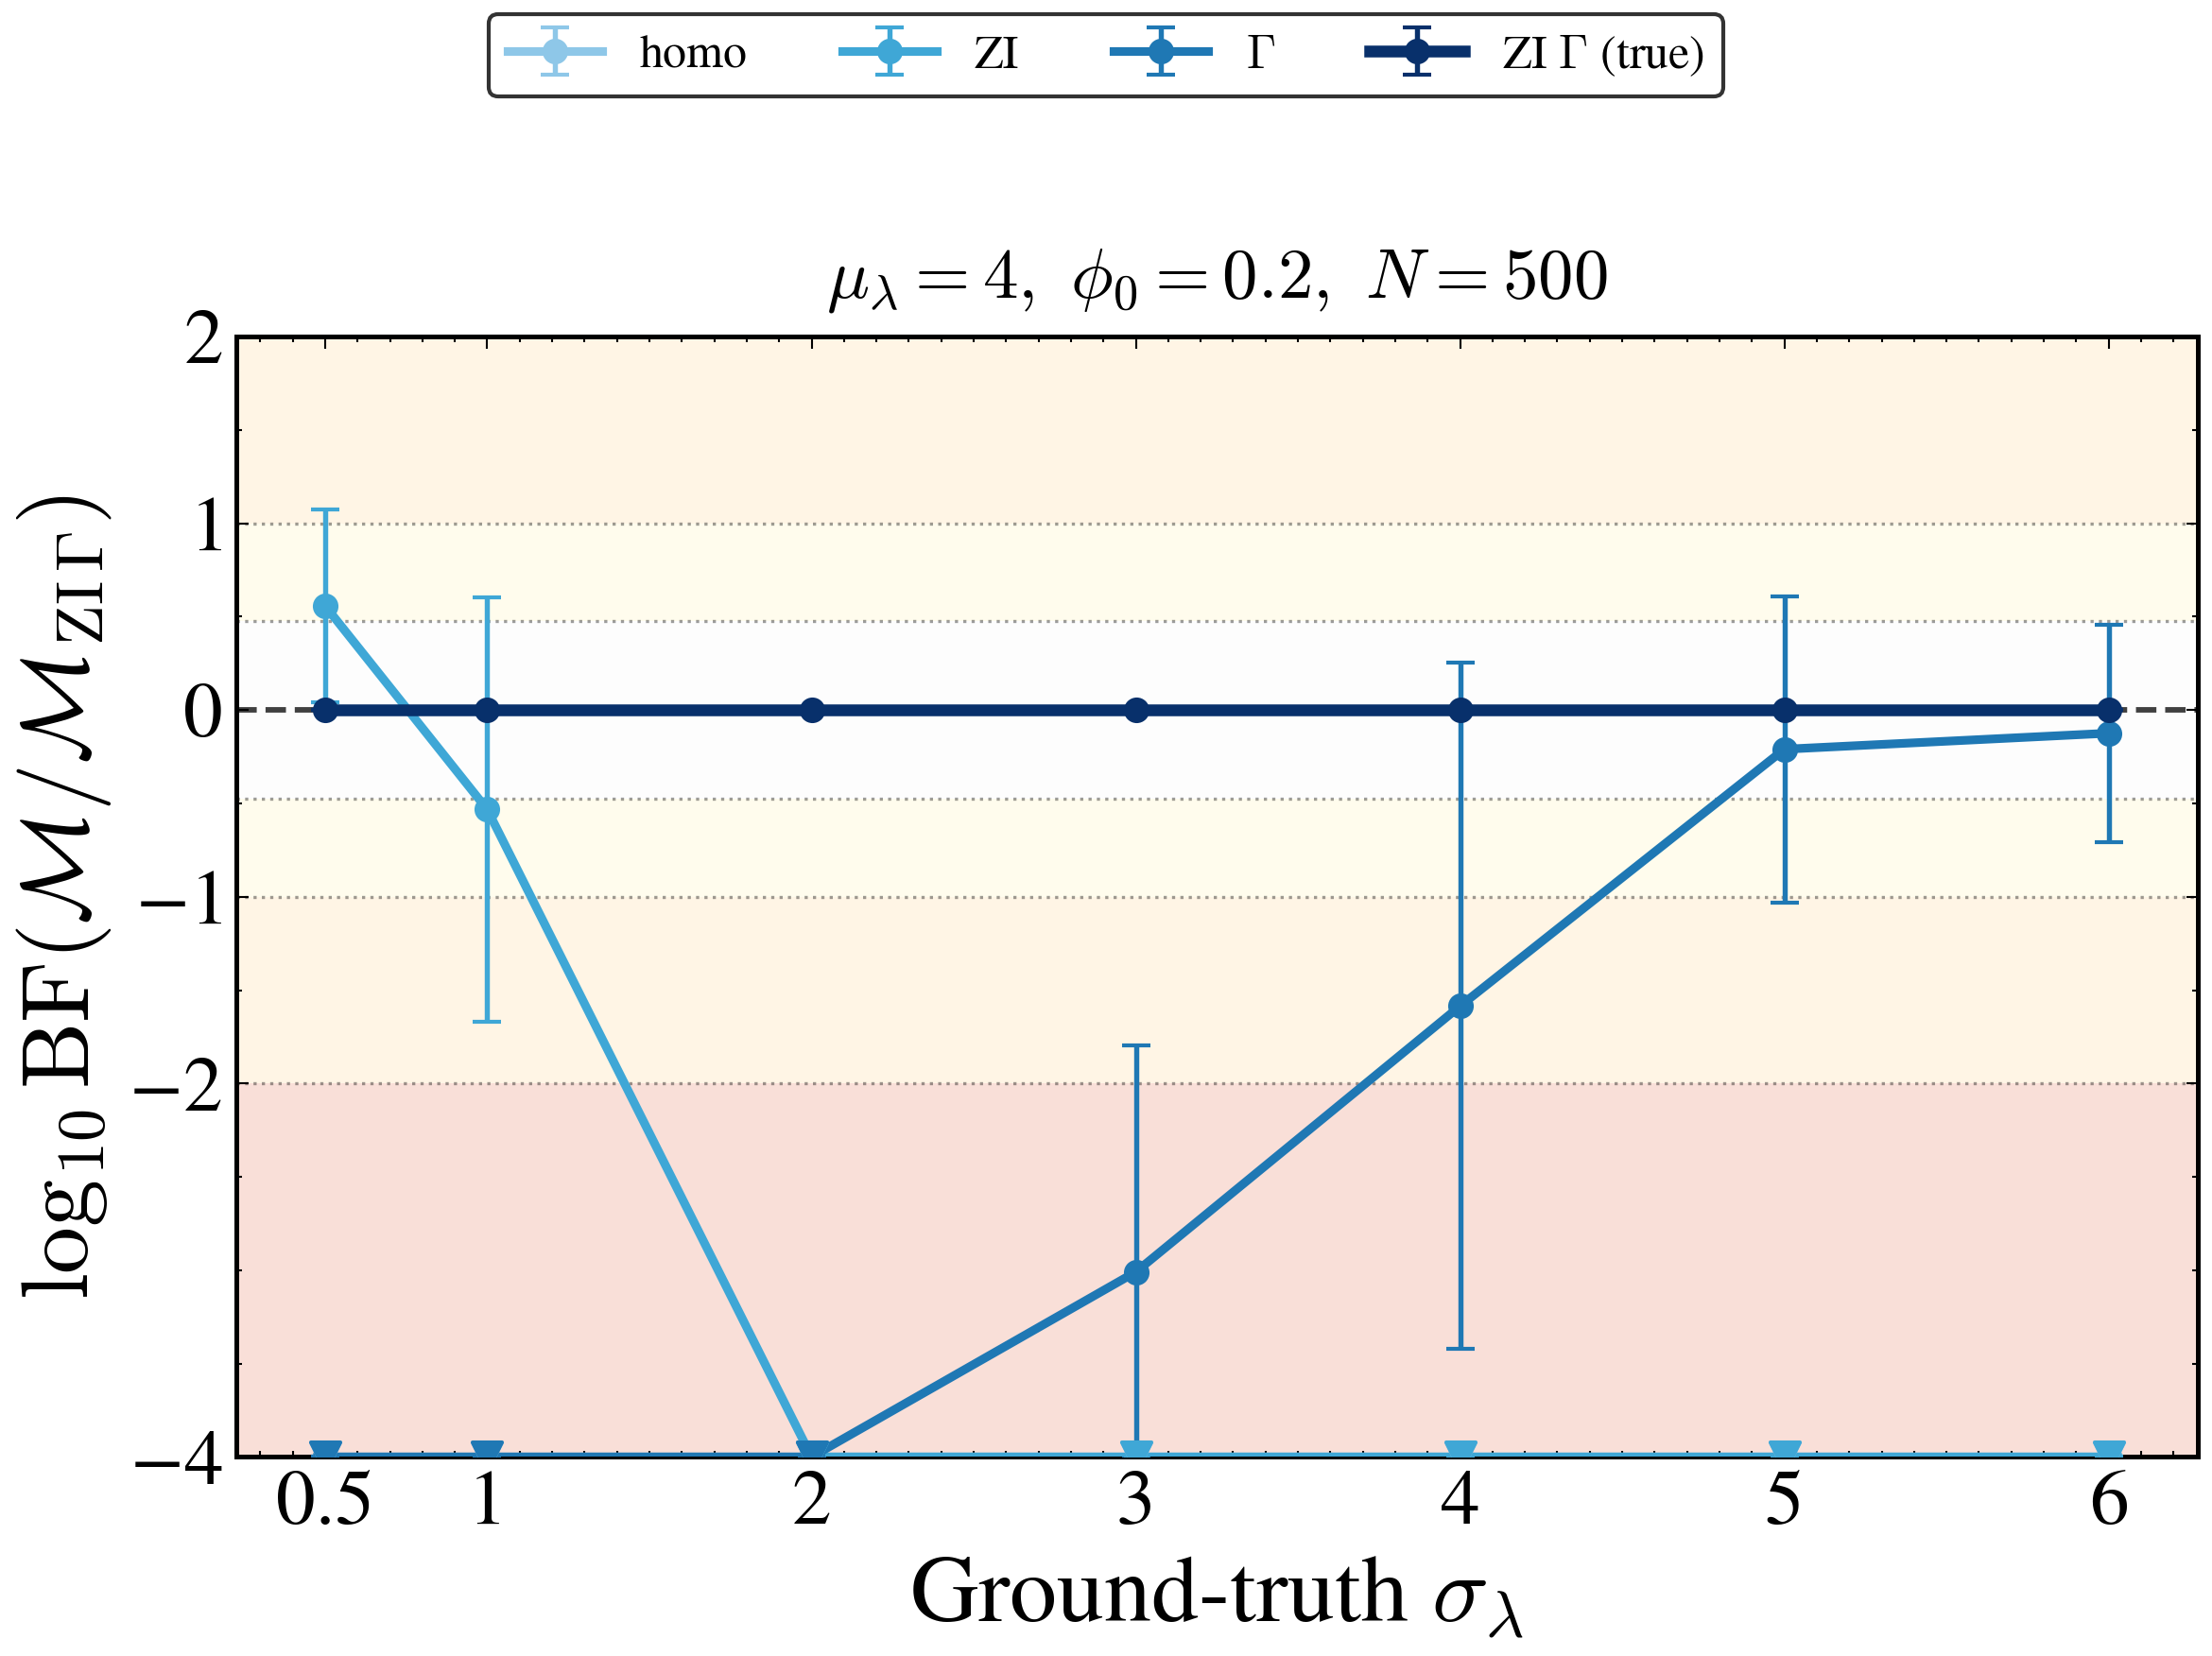

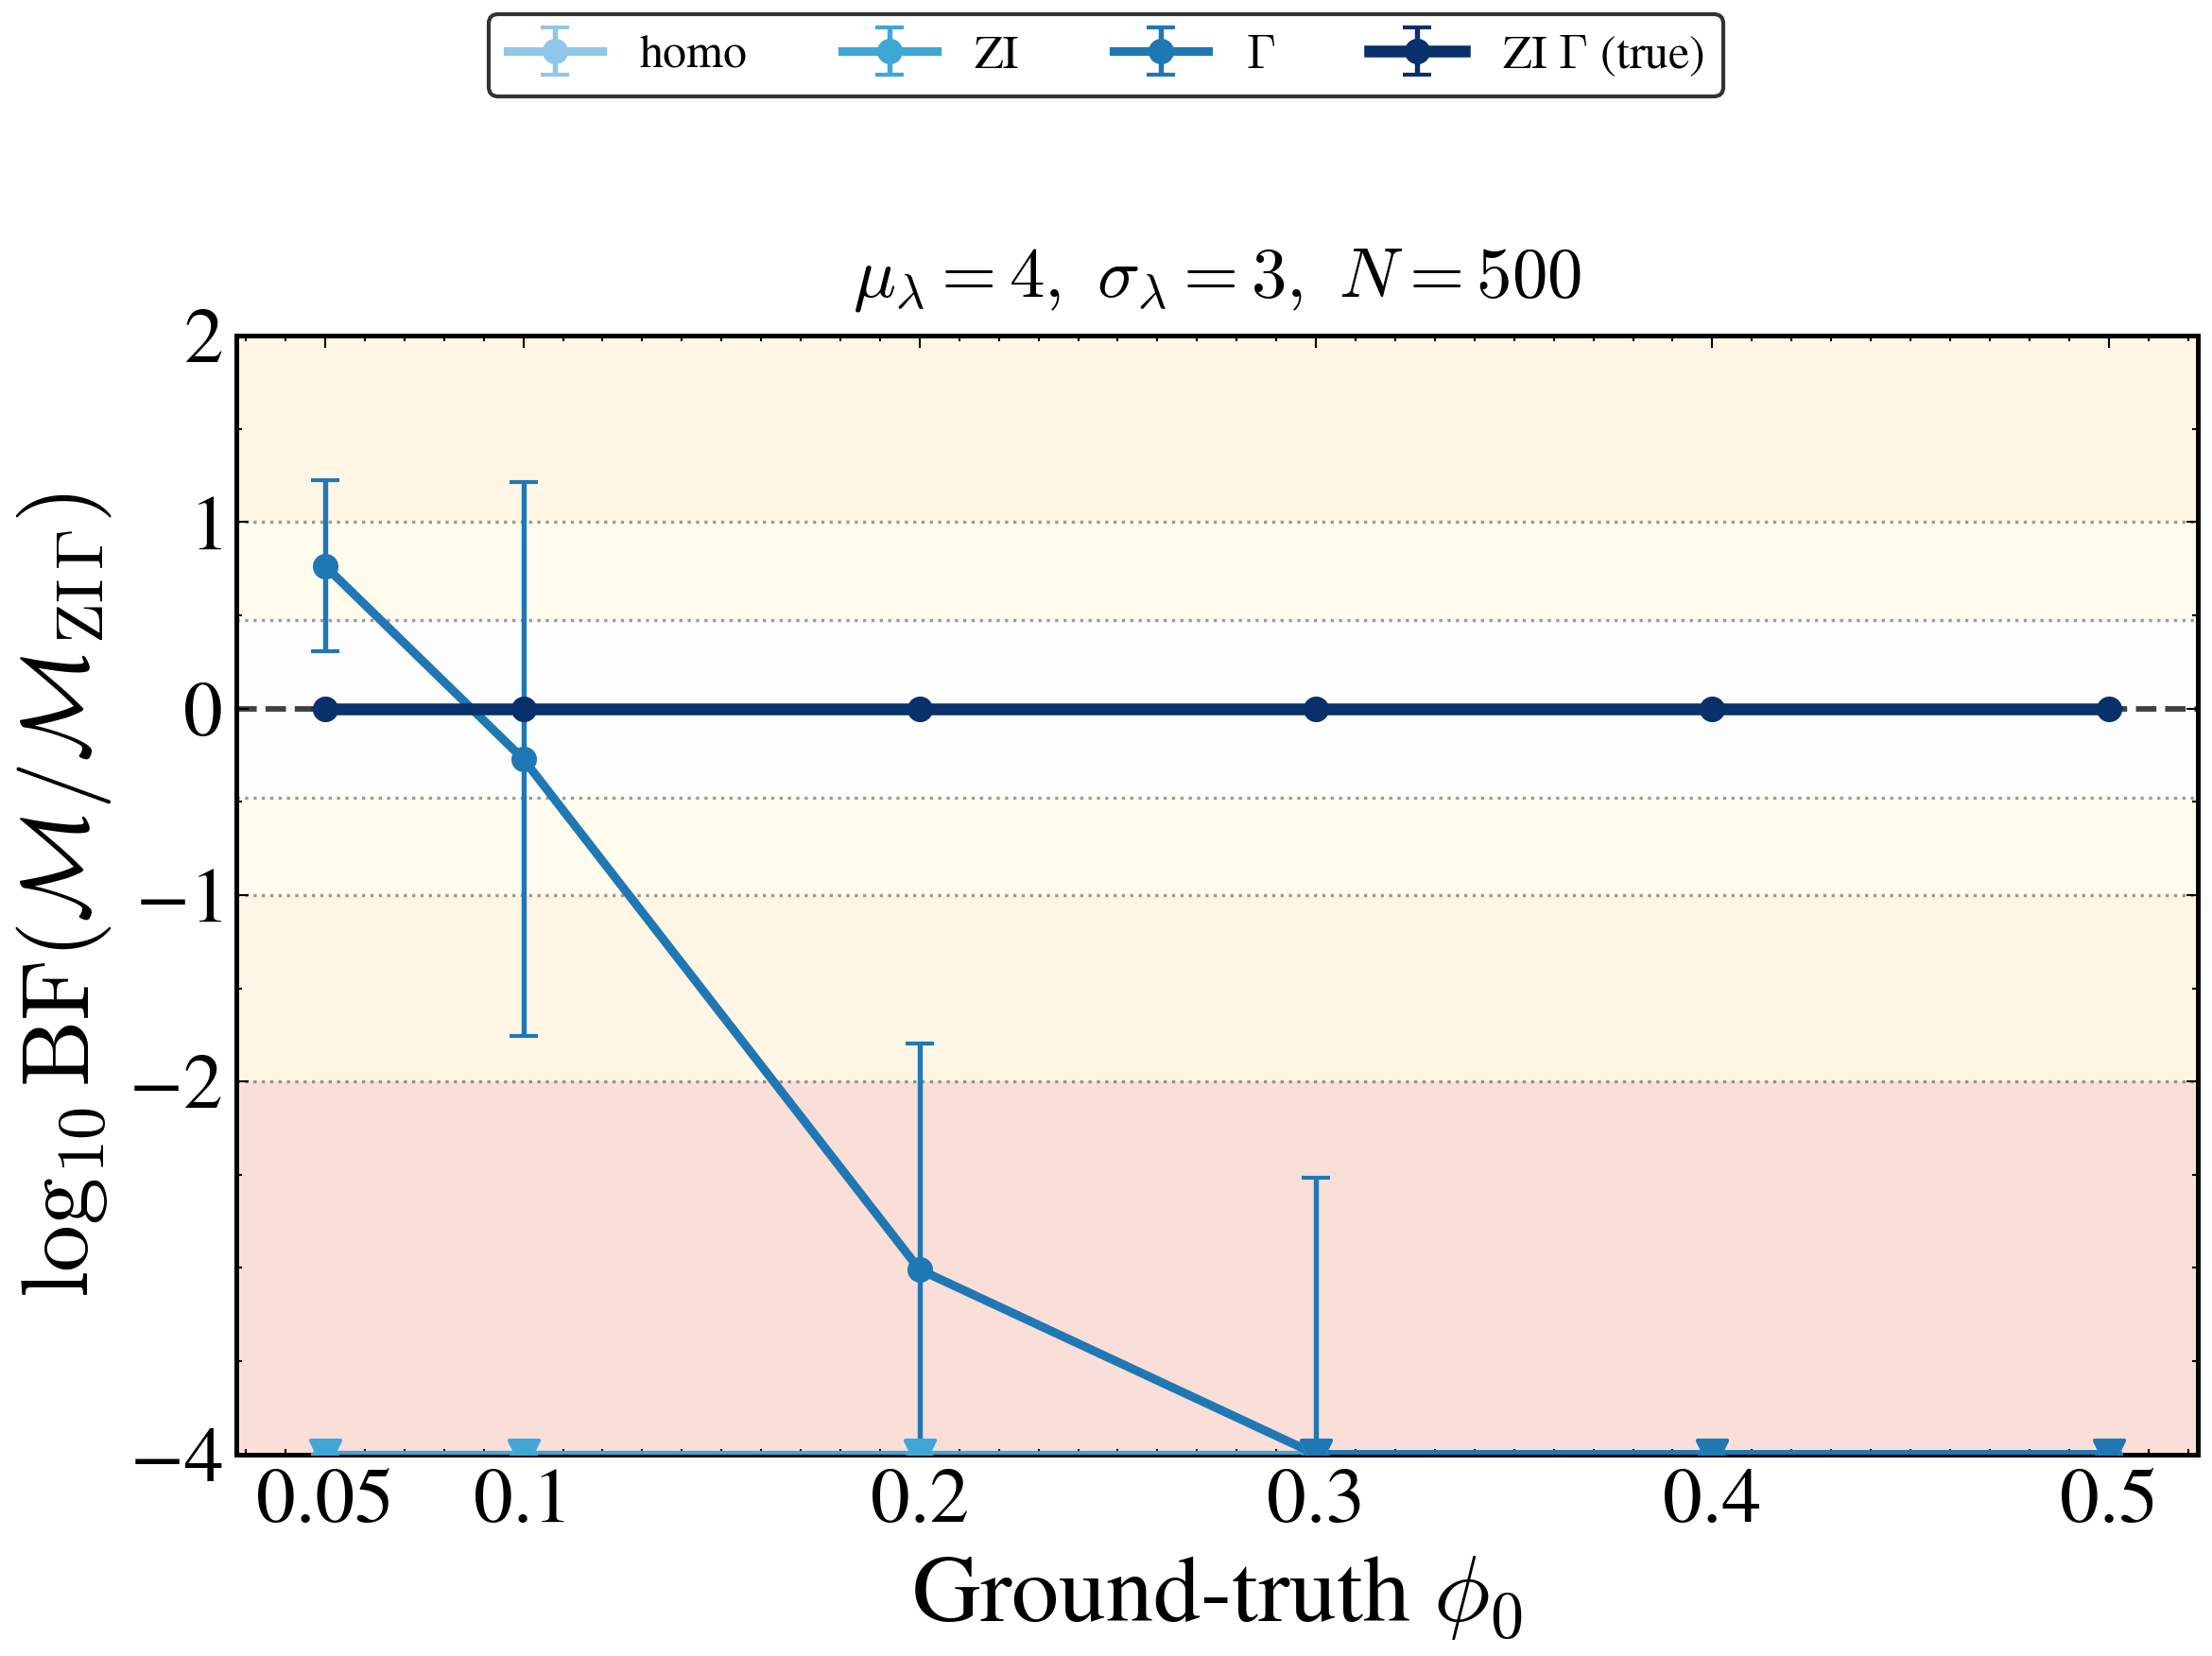

(PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_1/figures/part_2_bf_groundtruth/bf_vs_groundtruth_sigma_lambda_no1_n500.svg'),
 PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_1/figures/part_2_bf_groundtruth/bf_vs_groundtruth_phi0_no1_n500.svg'))

In [30]:
sigma_sweep = select_sweep(logml_df, "sigma_lambda")
p_zero_sweep = select_sweep(logml_df, "p_zero")

ylabel = (
    rf"$\log_{{10}}\mathrm{{BF}}"
    rf"(\mathcal{{M}}/\mathcal{{M}}_{{{MODEL_MATH[REFERENCE_MODEL]}}})$"
)


# ------------------------------------------------------------
# Figure 1: BF versus ground-truth sigma_lambda
# ------------------------------------------------------------
fig_sigma, ax_sigma = plt.subplots(figsize=(8.0, 5.8), dpi=300)

plot_model_sweep(
    ax_sigma,
    sigma_sweep,
    x_col="sigma_lambda",
    baseline_x=BASELINE_SIGMA,
    xlabel=r"Ground-truth $\sigma_\lambda$",
    title=(
        rf"$\mu_\lambda={run_config['mu_lambda']:g},\ "
        rf"\phi_0={BASELINE_P_ZERO:g},\ N={N_CELLS}$"
    ),
    xticks=[0.5, 1, 2, 3, 4, 5, 6],
)

ax_sigma.set_ylabel(ylabel, fontsize=24)

handles, labels = ax_sigma.get_legend_handles_labels()
fig_sigma.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=True,
    edgecolor="black",
    fontsize=12,
)

fig_sigma.tight_layout(rect=(0, 0, 1, 0.90))

SIGMA_SWEEP_PATH = (
    FIGURE_ROOT
    / f"bf_vs_groundtruth_sigma_lambda_no1_n{N_CELLS}.svg"
)
fig_sigma.savefig(
    SIGMA_SWEEP_PATH,
    bbox_inches="tight",
    transparent=True,
)
plt.show()


# ------------------------------------------------------------
# Figure 2: BF versus ground-truth phi_0
# ------------------------------------------------------------
fig_pzero, ax_pzero = plt.subplots(figsize=(8.0, 5.8), dpi=300)

plot_model_sweep(
    ax_pzero,
    p_zero_sweep,
    x_col="p_zero",
    baseline_x=BASELINE_P_ZERO,
    xlabel=r"Ground-truth $\phi_0$",
    title=(
        rf"$\mu_\lambda={run_config['mu_lambda']:g},\ "
        rf"\sigma_\lambda={BASELINE_SIGMA:g},\ N={N_CELLS}$"
    ),
    xticks=[0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
)

ax_pzero.set_ylabel(ylabel, fontsize=24)

handles, labels = ax_pzero.get_legend_handles_labels()
fig_pzero.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=True,
    edgecolor="black",
    fontsize=12,
)

fig_pzero.tight_layout(rect=(0, 0, 1, 0.90))

PZERO_SWEEP_PATH = (
    FIGURE_ROOT
    / f"bf_vs_groundtruth_phi0_no1_n{N_CELLS}.svg"
)
fig_pzero.savefig(
    PZERO_SWEEP_PATH,
    bbox_inches="tight",
    transparent=True,
)
plt.show()


SIGMA_SWEEP_PATH, PZERO_SWEEP_PATH
